In [2]:
#task 1
import pandas as pd

# Load dataset
df = pd.read_excel("Online-Store-Orders.xlsx")

# Display first few rows
print(df.head())

# Dataset shape
print(df.shape)

# Dataset information
print(df.info())

# Statistical summary
print(df.describe())

# Missing values
print(df.isnull().sum())

# Data types
print(df.dtypes)

     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  
2   FREESHIP  

In [3]:
#task 2
import numpy as np

missing_values = df.isnull().sum()

print(missing_values)

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64


In [4]:
missing_percent = (df.isnull().sum()/len(df))*100

print(missing_percent)

OrderID             0.00
Date                0.00
CustomerID          0.00
Product             0.00
Quantity            0.00
UnitPrice           0.00
ShippingAddress     0.00
PaymentMethod       0.00
OrderStatus         0.00
TrackingNumber      0.00
ItemsInCart         0.00
CouponCode         25.75
ReferralSource      0.00
TotalPrice          0.00
dtype: float64


In [4]:
#handling missing values
df["CouponCode"] = df["CouponCode"].fillna("No Coupon")

In [5]:
#verify
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [6]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [7]:
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year
df["DayName"] = df["Date"].dt.day_name()

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Month,Year,DayName
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,1,2023,Wednesday
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,8,2024,Friday
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2,2024,Tuesday
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,10,2023,Sunday
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,5,2025,Thursday


          Quantity    UnitPrice  ItemsInCart   TotalPrice
count  1200.000000  1200.000000  1200.000000  1200.000000
mean      2.945833   356.412750     5.485000  1053.968300
std       1.407557   197.177146     2.281983   819.856558
min       1.000000    11.390000     1.000000    11.390000
25%       2.000000   186.062500     4.000000   410.520000
50%       3.000000   364.210000     5.000000   823.615000
75%       4.000000   521.570000     7.000000  1578.475000
max       5.000000   699.930000    10.000000  3456.400000


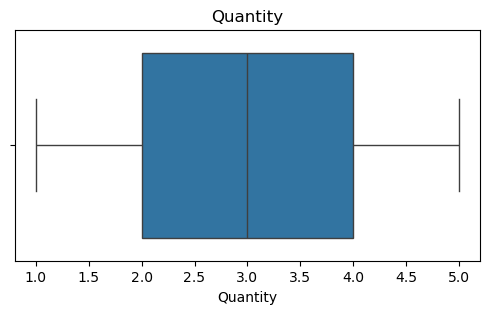

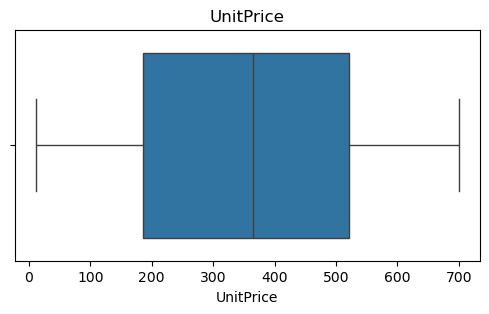

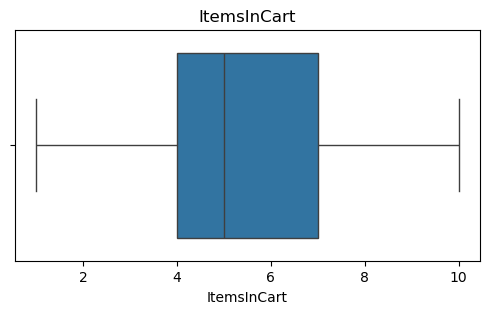

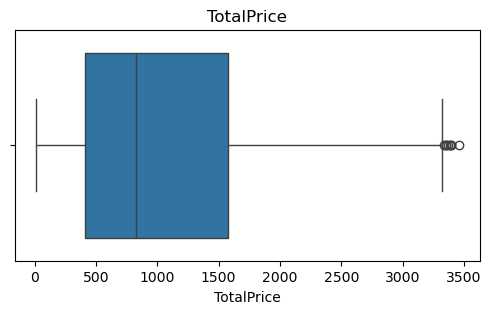

In [8]:
numerical_cols = [
    "Quantity",
    "UnitPrice",
    "ItemsInCart",
    "TotalPrice"
]

print(df[numerical_cols].describe())

import seaborn as sns
import matplotlib.pyplot as plt

for col in numerical_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [9]:
df.to_csv(
    "OnlineStore_Cleaned.csv",
    index=False
)

In [10]:
print(df.shape)

print(df["Product"].nunique())
print(df["PaymentMethod"].nunique())
print(df["OrderStatus"].nunique())
print(df["ReferralSource"].nunique())

(1200, 17)
7
5
5
5


In [11]:
#task 3
product_sales = df.groupby("Product")["TotalPrice"].sum().sort_values(ascending=False)

print(product_sales)

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64


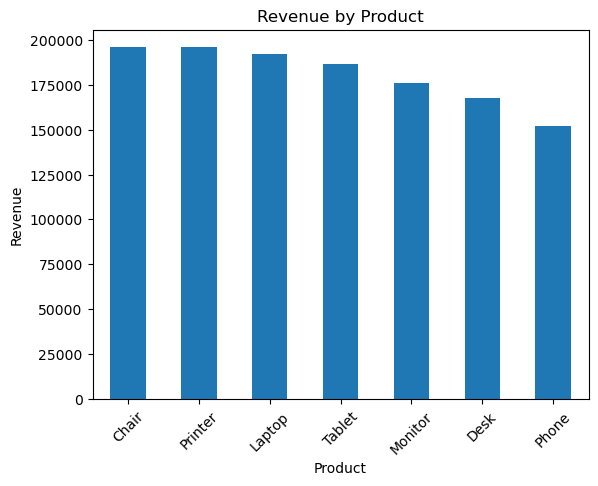

In [12]:
import matplotlib.pyplot as plt

product_sales.plot(kind="bar")

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [13]:
payment_count = df["PaymentMethod"].value_counts()

print(payment_count)

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64


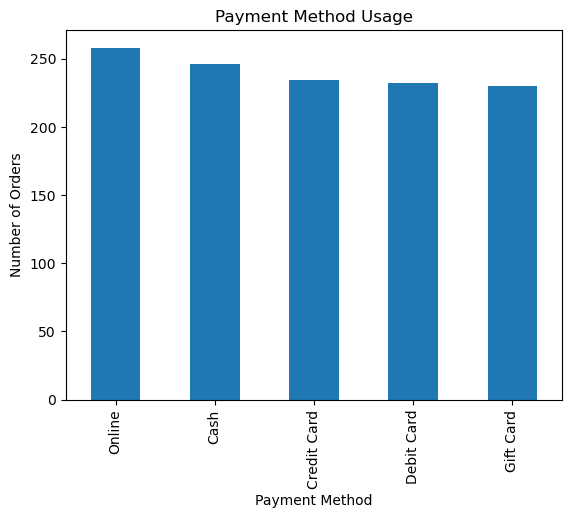

In [14]:
payment_count.plot(kind="bar")

plt.title("Payment Method Usage")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.show()

In [15]:
status_count = df["OrderStatus"].value_counts()

print(status_count)

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64


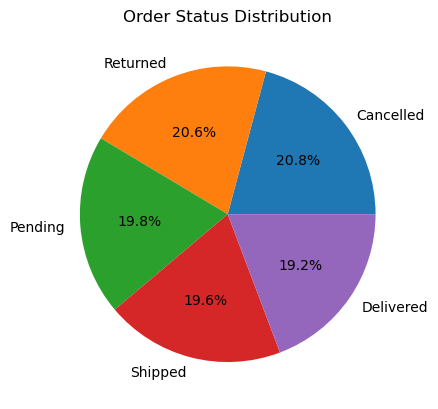

In [16]:
status_count.plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")
plt.title("Order Status Distribution")
plt.show()

In [17]:
referral_sales = df.groupby("ReferralSource")["TotalPrice"].sum()

print(referral_sales)

ReferralSource
Email        261808.55
Facebook     250410.90
Google       250441.48
Instagram    275285.45
Referral     226815.58
Name: TotalPrice, dtype: float64


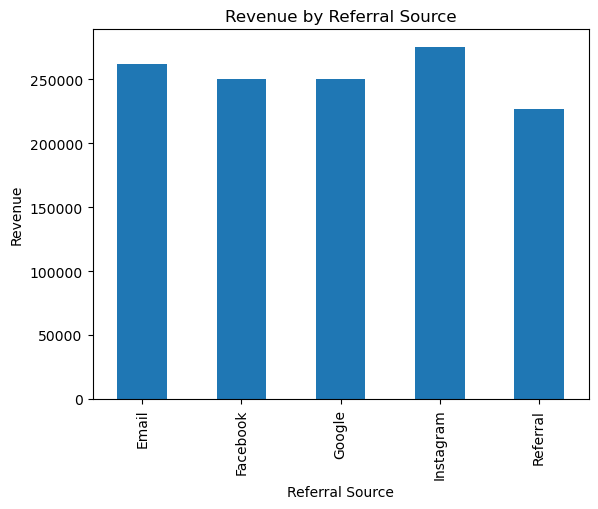

In [18]:
referral_sales.plot(kind="bar")

plt.title("Revenue by Referral Source")
plt.xlabel("Referral Source")
plt.ylabel("Revenue")
plt.show()

In [19]:
monthly_sales = df.groupby("Month")["TotalPrice"].sum()

print(monthly_sales)

Month
1     124313.23
2     112344.78
3     123840.93
4     109186.05
5     135142.59
6     170616.13
7      85784.64
8      86343.21
9      69321.65
10     89834.82
11     75493.43
12     82540.50
Name: TotalPrice, dtype: float64


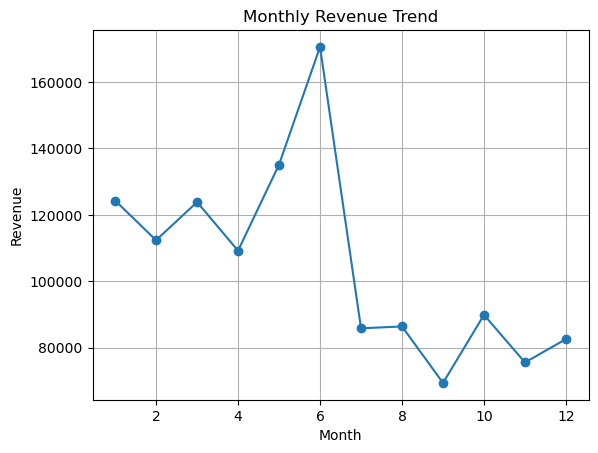

In [20]:
monthly_sales.plot(marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

In [21]:
coupon_sales = df.groupby("CouponCode")["TotalPrice"].sum()

print(coupon_sales.sort_values(ascending=False))

CouponCode
FREESHIP    335036.99
SAVE10      304840.02
WINTER15    302483.54
Name: TotalPrice, dtype: float64


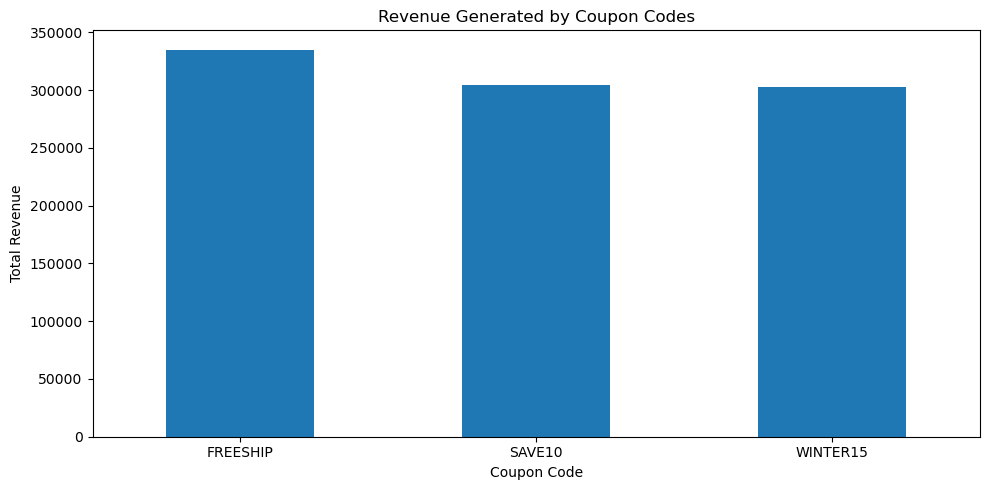

In [23]:
import matplotlib.pyplot as plt

coupon_sales = (
    df.groupby("CouponCode")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
coupon_sales.plot(kind="bar")

plt.title("Revenue Generated by Coupon Codes")
plt.xlabel("Coupon Code")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [24]:
#task4

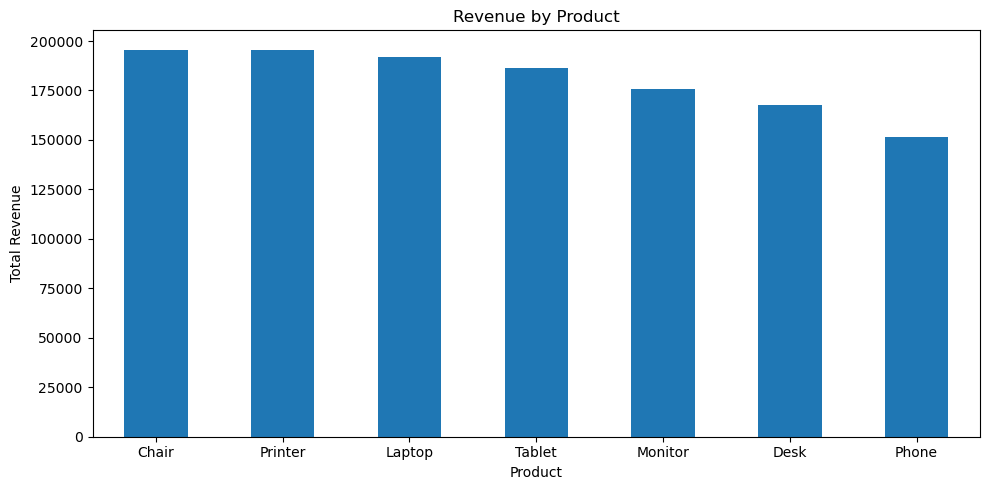

In [38]:
#Revenue by Product
product_sales = (
    df.groupby("Product")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
product_sales.plot(kind="bar")

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

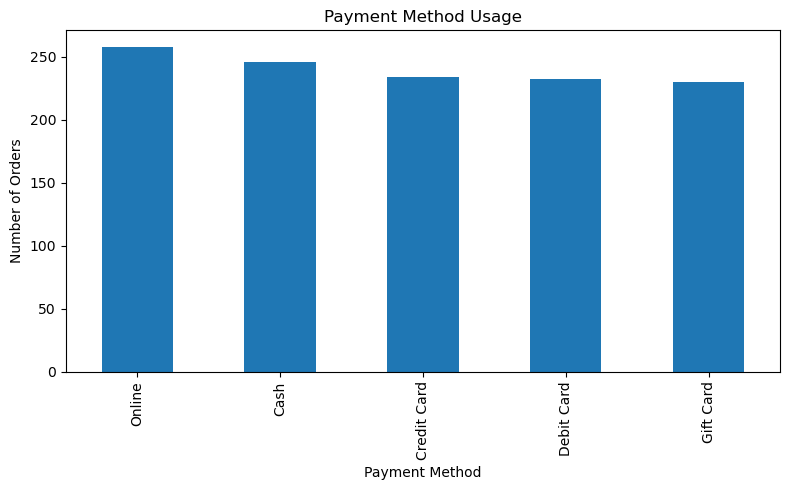

In [27]:
#Payment Method Usage
payment_count = df["PaymentMethod"].value_counts()

plt.figure(figsize=(8,5))
payment_count.plot(kind="bar")

plt.title("Payment Method Usage")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

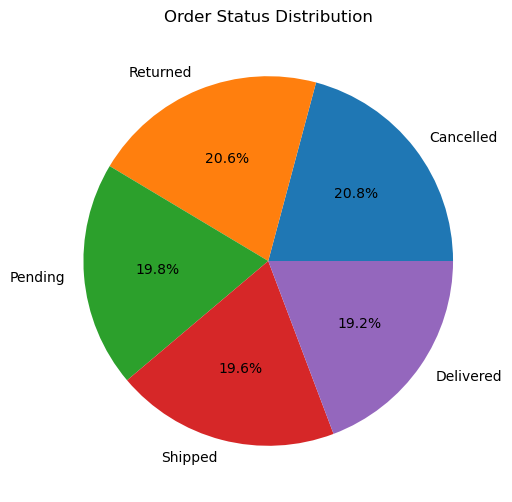

In [28]:
#Order Status Distribution
status_count = df["OrderStatus"].value_counts()

plt.figure(figsize=(8,6))
status_count.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Order Status Distribution")
plt.ylabel("")

plt.show()

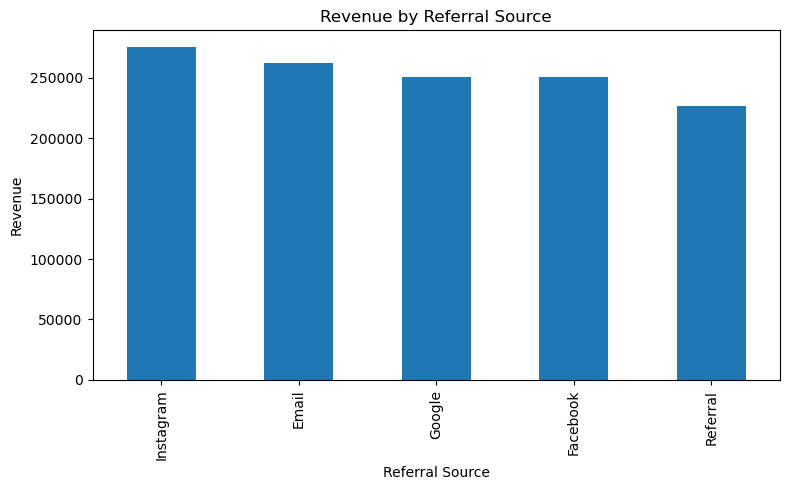

In [29]:
#Revenue by Referral Source
referral_sales = (
    df.groupby("ReferralSource")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
referral_sales.plot(kind="bar")

plt.title("Revenue by Referral Source")
plt.xlabel("Referral Source")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

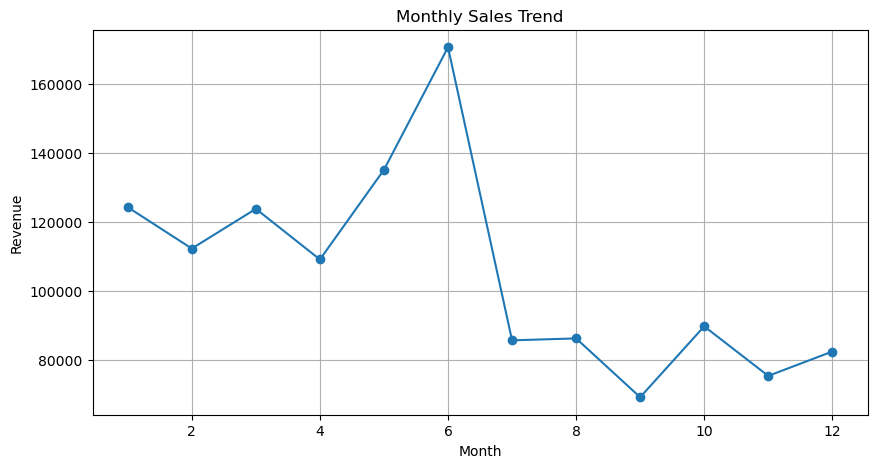

In [30]:
#Monthly Sales Trend
monthly_sales = (
    df.groupby("Month")["TotalPrice"]
      .sum()
)

plt.figure(figsize=(10,5))

monthly_sales.plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

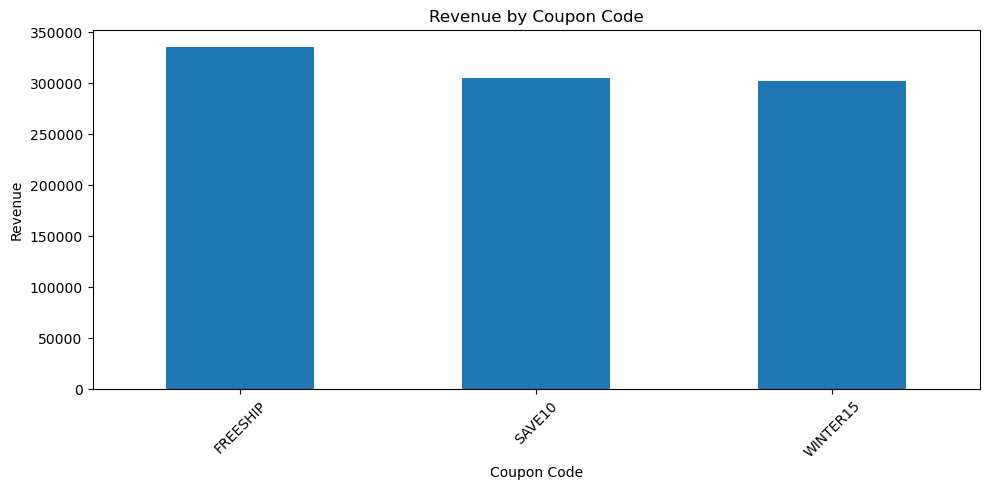

In [31]:
#Coupon Performance
coupon_sales = (
    df.groupby("CouponCode")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

coupon_sales.plot(kind="bar")

plt.title("Revenue by Coupon Code")
plt.xlabel("Coupon Code")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [39]:
#task5

In [40]:
columns_to_drop = [
    "OrderID",
    "CustomerID",
    "TrackingNumber",
    "Date"
]

df_model = df.drop(columns=columns_to_drop)

In [41]:
X = df_model.drop("TotalPrice", axis=1)

y = df_model["TotalPrice"]

In [42]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [45]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [47]:
y_pred = lr.predict(X_test)
y_pred

array([-275.7129776 , 2392.30175482,  397.89779137, -302.75556465,
       2014.24483442,   40.89505654, -372.50138352, 1869.97887387,
       -229.79063782, 1463.26749148, 1891.31796622,  996.8615588 ,
       -843.29133488, 1036.77963469, -626.03525142, 2428.63110468,
       2031.29577679, 1300.20991105, 1966.09077604, 2918.26953463,
       1208.10711301, 1268.55853605, 1026.16222779, 2001.56364416,
       1562.10396984, 1083.48197396, 1151.53921668,  912.47282581,
         72.54678354, 2732.58957372, 2475.47689397, 1294.4218677 ,
       1301.99781161, 1021.7373447 , 1150.32431674, 1802.94321984,
       -239.92133342, 1235.02213057,  917.89043139, 1889.78016267,
       2712.48451316, 2821.80362454, 1294.03435159, 1406.97353522,
       1228.98881453, 1946.35185127, 1409.57955733, 1126.96427372,
       1115.6563271 ,  186.0015237 , 1923.88504749,   82.22580756,
       2686.76694393, 1230.3206386 ,  918.33035039,  380.30752614,
       1676.44955808,  516.0372168 ,  559.29172393,   61.58361

In [48]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)

MAE: 281.2313406757528
MSE: 128379.41221965753
R² Score: 0.8312637739387987


In [49]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(results.head(10))

       Actual    Predicted
1178    70.24  -275.712978
865   2709.48  2392.301755
101    381.02   397.897791
439    146.32  -302.755565
58    1898.76  2014.244834
1120   195.86    40.895057
323    150.17  -372.501384
974   1333.90  1869.978874
411     79.02  -229.790638
855   1203.05  1463.267491


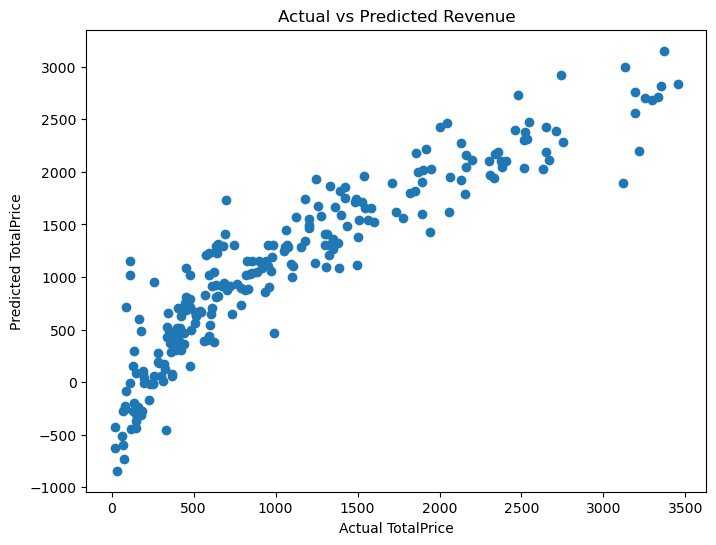

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual TotalPrice")
plt.ylabel("Predicted TotalPrice")

plt.title("Actual vs Predicted Revenue")

plt.show()

In [51]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print(
    "Random Forest R²:",
    r2_score(y_test, rf_pred)
)

Random Forest R²: 0.9996784737509996


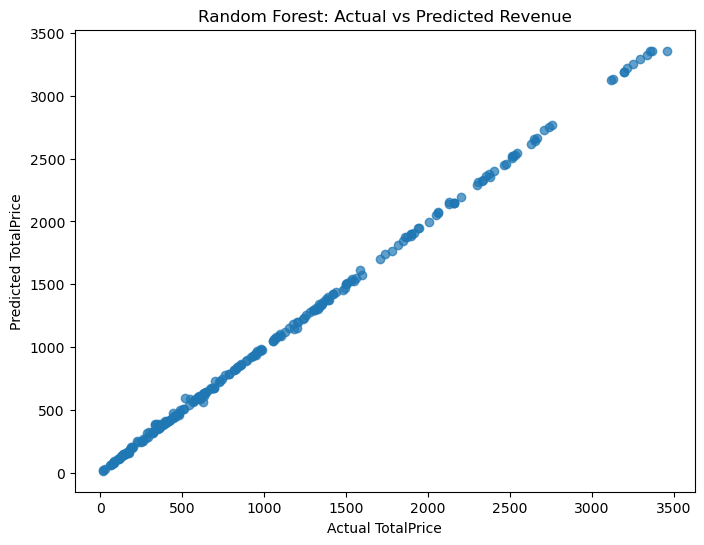

In [54]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_pred, alpha=0.7)

plt.xlabel("Actual TotalPrice")
plt.ylabel("Predicted TotalPrice")
plt.title("Random Forest: Actual vs Predicted Revenue")

plt.show()

In [55]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": rf_pred
})

print(comparison.head(20))

       Actual  Predicted
1178    70.24    72.7064
865   2709.48  2723.7556
101    381.02   381.4307
439    146.32   149.6016
58    1898.76  1901.5684
1120   195.86   205.3567
323    150.17   151.7201
974   1333.90  1341.1171
411     79.02    81.0478
855   1203.05  1152.5530
820   3119.05  3125.2365
44    1100.36  1103.5386
49      30.44    31.8191
849    857.40   866.1648
240     17.24    21.8592
170   2651.76  2638.6220
523   2631.16  2612.1124
765   1069.82  1068.7896
838   2308.32  2310.6548
423   2740.80  2753.6468


In [56]:
comparison["Error"] = comparison["Actual"] - comparison["Predicted"]

print(comparison.head(20))

       Actual  Predicted    Error
1178    70.24    72.7064  -2.4664
865   2709.48  2723.7556 -14.2756
101    381.02   381.4307  -0.4107
439    146.32   149.6016  -3.2816
58    1898.76  1901.5684  -2.8084
1120   195.86   205.3567  -9.4967
323    150.17   151.7201  -1.5501
974   1333.90  1341.1171  -7.2171
411     79.02    81.0478  -2.0278
855   1203.05  1152.5530  50.4970
820   3119.05  3125.2365  -6.1865
44    1100.36  1103.5386  -3.1786
49      30.44    31.8191  -1.3791
849    857.40   866.1648  -8.7648
240     17.24    21.8592  -4.6192
170   2651.76  2638.6220  13.1380
523   2631.16  2612.1124  19.0476
765   1069.82  1068.7896   1.0304
838   2308.32  2310.6548  -2.3348
423   2740.80  2753.6468 -12.8468


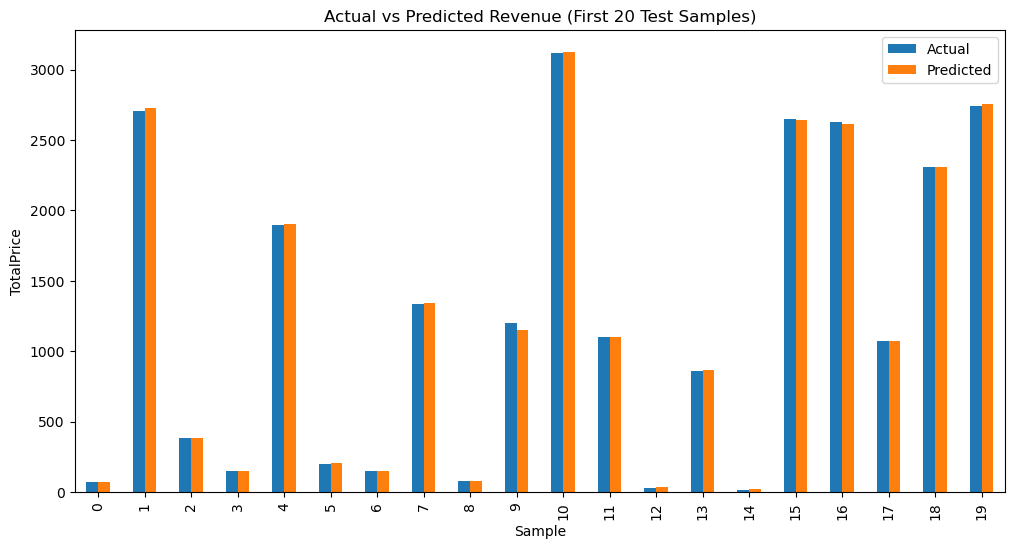

In [57]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": rf_pred
}).head(20)

comparison.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Actual vs Predicted Revenue (First 20 Test Samples)")
plt.xlabel("Sample")
plt.ylabel("TotalPrice")

plt.show()